In [1]:
import networkx as nx
import random
import warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
interval_labeling = pd.read_csv("intervalli_glucosio.csv", delimiter=',')
df = pd.DataFrame(interval_labeling)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])
df["duration"] = ((df["end_time"] - df["start_time"]).dt.total_seconds() / 60).round(2)
df

,symbol,start_time,end_time,label,duration
0,b,2024-08-26 00:00:29,2024-08-26 01:40:29,high,100.00
1,c,2024-08-26 01:45:29,2024-08-26 07:55:29,normal,370.00
2,b,2024-08-26 08:00:29,2024-08-26 10:20:28,high,139.98
3,a,2024-08-26 10:25:28,2024-08-26 10:50:29,extremely_high,25.02
4,b,2024-08-26 10:55:28,2024-08-26 11:00:28,high,5.00
...,...,...,...,...,...
205,c,2024-09-08 10:41:33,2024-09-08 11:16:33,normal,35.00
206,d,2024-09-08 11:21:33,2024-09-08 11:36:32,low,14.98
207,e,2024-09-08 11:41:32,2024-09-08 11:51:33,extremely_low,10.02
208,d,2024-09-08 11:56:33,2024-09-08 11:56:33,low,0.00


 ## GRAFO CON AUTOMA DETERMINISTICO


In [3]:
arr = []
for index, row in df.iterrows():
    arr.append((row['label'], row['duration']))

seq = arr

G = nx.DiGraph()

for i in range(len(seq) - 1):
    src, dur_src = seq[i]
    dst, dur_dst = seq[i + 1]
    if G.has_edge(src, dst):
        G[src][dst]["count"] += 1
        G[src][dst]["durations"].append(dur_dst)
    else:
        G.add_edge(src, dst, count=1, durations=[dur_dst])


## EVENTI SU AUTOMA DETERMINISTICO

In [4]:
def most_n_frequent_events(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        #durations = [s[1] for s in seq[i:i+n]]
        ngrams[labels]['count'] += 1
        #ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Calcolo media durate per ogni transizione ---
for u, v, data in G.edges(data=True):
    data["mean_duration"] = sum(data["durations"]) / len(data["durations"])

# --- Calcolo delle probabilità di transizione ---
for u in G.nodes():
    total = sum(G[u][v]["count"] for v in G.successors(u))
    for v in G.successors(u):
        if total > 0:
            G[u][v]["prob"] = G[u][v]["count"] / total
        else:
            G[u][v]["prob"] = 0.0  # fallback se nessuna uscita

# --- Stampa riepilogativa delle transizioni ---
print("\n Modello probabilistico delle transizioni:\n")
for u in G.nodes():
    successors = list(G.successors(u))
    if not successors:
        print(f"{u} → [nessuna uscita]")
        continue
    print(f"\nDa stato '{u}' posso passare a:")
    for v in successors:
        prob = G[u][v]["prob"]
        mean_dur = round(G[u][v]["mean_duration"], 2)
        count = G[u][v]["count"]
        print(f"  ↳ {v:<16} | Probabilità: {prob:.2f} | Count: {count:<3} | Durata media: {mean_dur} min")

# --- Eventi più frequenti ---
events = most_n_frequent_events(seq, 4)
print("\n Esempio di 4 pattern più frequenti:")
for k, v in sorted(events.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    print(f"{k} | count={v['count']}")


 Modello probabilistico delle transizioni:


Da stato 'high' posso passare a:
  ↳ normal           | Probabilità: 0.83 | Count: 59  | Durata media: 140.17 min
  ↳ extremely_high   | Probabilità: 0.17 | Count: 12  | Durata media: 70.0 min

Da stato 'normal' posso passare a:
  ↳ high             | Probabilità: 0.65 | Count: 58  | Durata media: 33.19 min
  ↳ low              | Probabilità: 0.35 | Count: 31  | Durata media: 16.29 min

Da stato 'extremely_high' posso passare a:
  ↳ high             | Probabilità: 1.00 | Count: 12  | Durata media: 28.33 min

Da stato 'low' posso passare a:
  ↳ normal           | Probabilità: 0.91 | Count: 31  | Durata media: 208.71 min
  ↳ extremely_low    | Probabilità: 0.09 | Count: 3   | Durata media: 5.01 min

Da stato 'extremely_low' posso passare a:
  ↳ low              | Probabilità: 1.00 | Count: 3   | Durata media: 0.0 min

 Esempio di 4 pattern più frequenti:
('normal', 'high', 'normal', 'high') | count=41
('high', 'normal', 'high', 'normal') | co

## SIMULO AUTOMA DETERMINISTICO


Sequenza simulata: [('high', 30, 180), ('normal', 100, 175.72241897205262), ('high', 30, 180), ('extremely_high', 65, 250), ('high', 15, 249), ('normal', 170, 168.61077733670894), ('high', 25, 181.36934812006513), ('normal', 50, 171.3132539102417), ('high', 40, 183.7513027404194), ('normal', 140, 177.83547073244392), ('high', 40, 180), ('normal', 155, 175.48965784294379), ('high', 15, 181.2010345893962), ('normal', 170, 174.21754215348597), ('high', 25, 180), ('normal', 170, 169.91156174691253), ('low', 5, 80), ('normal', 190, 86.35376629915507), ('high', 35, 182.67013417024646), ('normal', 105, 178.02046235417913), ('low', 5, 80), ('extremely_low', 5, 55), ('low', 5, 56), ('normal', 215, 85.65151548974836), ('low', 10, 80), ('normal', 315, 84.27778690672339), ('high', 25, 180), ('normal', 205, 173.38486077418716), ('high', 30, 180), ('normal', 135, 173.30308556960756), ('low', 10, 80), ('normal', 175, 86.29031029173443), ('high', 20, 180), ('extremely_high', 80, 262.92037707741946), 

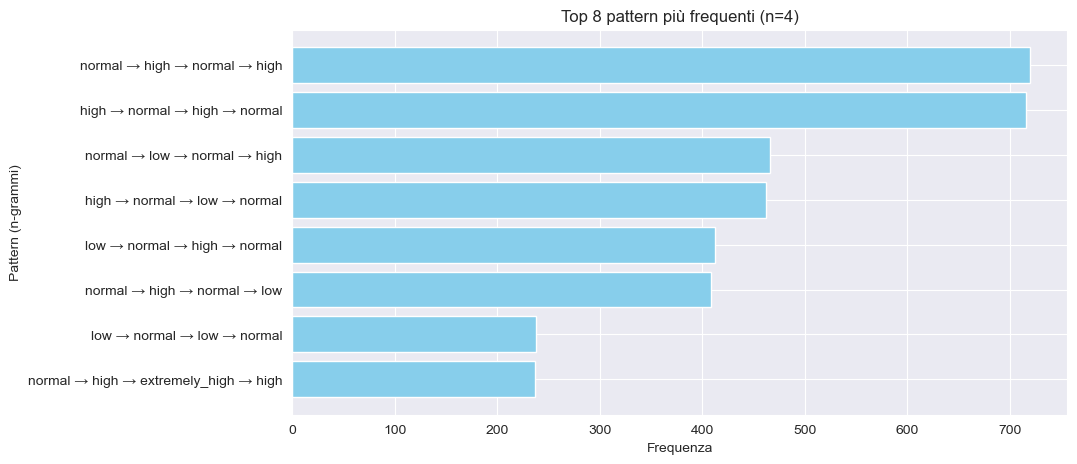

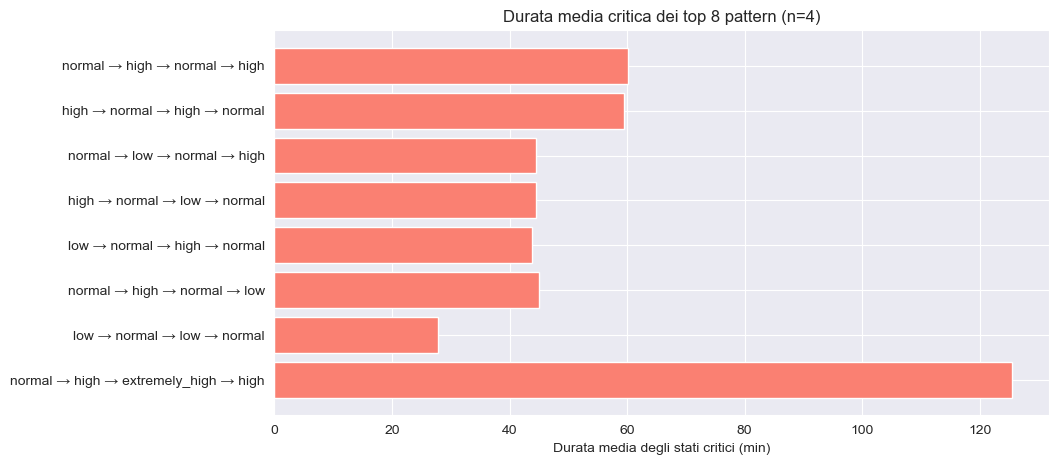

In [64]:


def calculate_gmi(gluc_data):
    """Calcola GMI e media glucosio da una lista di valori."""
    gluc_values = []
    for g in gluc_data:
        if isinstance(g, str) and g.lower() == "basso":
            gluc_values.append(50)
        else:
            gluc_values.append(float(g))
    avg = np.mean(gluc_values)
    gmi = 3.31 + 0.02392 * avg
    if gmi < 7:
        gmi_color = "🟢"
    elif gmi < 8:
        gmi_color = "🟡"
    else:
        gmi_color = "🔴"
    return gmi, avg, gmi_color


def simulate_random_sequence_realistic(G, total_minutes=10000):
    """
    Genera una sequenza randomica più realistica,
    con valori di glucosio e calcolo GMI finale ponderato per durata.
    """

    state_order = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }

    glucose_ranges = {
        "extremely_low": (40, 55),
        "low": (56, 80),
        "normal": (81, 179),
        "high": (180, 249),
        "extremely_high": (250, 350)
    }

    # Scegli target color
    target_color = random.choices(
        ["verde", "giallo", "rosso"],
        weights=[0.6, 0.3, 0.1],
        k=1
    )[0]

    # Probabilità base per ciascun target
    if target_color == "verde":
        base_probs = {"normal": 0.8, "high": 0.1, "low": 0.07, "extreme": 0.03}
    elif target_color == "giallo":
        base_probs = {"normal": 0.5, "high": 0.25, "low": 0.2, "extreme": 0.05}
    else:  # rosso
        base_probs = {"normal": 0.2, "high": 0.4, "low": 0.3, "extreme": 0.1}

    duration_scale = 1.2
    noise_factor = 0.5

    state = "normal"
    seq = []
    tot_gluc = 0
    tot_time = 0
    elapsed = 0
    counts = defaultdict(int)

    while elapsed < total_minutes:
        successors = list(G.successors(state))
        if not successors:
            state = random.choice(list(G.nodes))
            successors = list(G.successors(state))
            if not successors:
                continue

        pulse = 1 + np.sin(elapsed / 5000) * random.uniform(-0.2, 0.2)
        succ_probs = []

        for s in successors:
            if s == "normal":
                base = base_probs["normal"]
            elif abs(state_order[s]) == 1:
                base = base_probs["high"] if state_order[s] > 0 else base_probs["low"]
            else:
                base = base_probs["extreme"]

            base *= random.uniform(0.8, 1.2) * pulse
            base *= 1 / (1 + counts[s] / 60)
            succ_probs.append(base)

        total_prob = sum(succ_probs)
        succ_probs = [p / total_prob for p in succ_probs]
        next_state = random.choices(successors, succ_probs)[0]

        mean_dur = G[state][next_state].get("mean_duration", 30)
        factor = duration_scale * (1.3 - 0.25 * abs(state_order[next_state]))
        dur = np.random.normal(mean_dur * factor, mean_dur * noise_factor)
        dur = max(1, min(dur, 240))

        gmin, gmax = glucose_ranges[next_state]
        glucose_value = round(random.uniform(gmin, gmax), 1)

        # Accumula valori ponderati per durata
        tot_gluc += glucose_value * dur
        tot_time += dur

        seq.append((next_state, round(dur, 1), glucose_value))
        counts[next_state] += 1
        state = next_state
        elapsed += dur

    # Calcola GMI ponderato
    avg_gluc = tot_gluc / tot_time
    gmi = 3.31 + 0.02392 * avg_gluc
    if gmi < 7:
        gmi_color = "🟢 Verde"
    elif 7 <= gmi <= 8:
        gmi_color = "🟡 Giallo"
    else:
        gmi_color = "🔴 Rosso"

    true_color = analyze_simulate_sequence_compact(seq)[0]

    return seq, true_color, gmi, avg_gluc, gmi_color


def simulate_sequence_with_duration(G, start="normal", steps=100, step_minutes=5):
    """
    Simula sequenze Markov con durate realistiche e step_minutes per letture.
    - Evita transizioni duplicate consecutive (normal->normal non viene generato)
    - Le letture successive dello stesso stato sono aggregate
    - Le glicemie cambiano gradualmente con random walk realistico
    """
    state = start
    seq = []

    glucose_ranges = {
        "extremely_low": (40, 55),
        "low": (56, 80),
        "normal": (81, 179),
        "high": (180, 249),
        "extremely_high": (250, 350)
    }

    prev_glucose = np.random.uniform(*glucose_ranges[state])
    prev_state_in_seq = None

    for _ in range(steps):
        # Successori diversi dallo stato corrente
        successors = [s for s in G.successors(state) if s != state]
        if not successors:
            successors = [state]  # fallback: resta nello stesso stato

        probs = [G[state][s]["prob"] for s in successors]
        next_state = random.choices(successors, probs)[0]

        # Determina durata dello stato
        data = G[state][next_state]
        if "mean_duration" in data:
            mean_dur = data["mean_duration"]
            dur = max(step_minutes, np.random.normal(mean_dur, mean_dur * 0.3))
        elif "durations" in data and len(data["durations"]) > 0:
            dur = random.choice(data["durations"])
        else:
            dur = random.uniform(5, 15)

        # Numero di letture in step_minutes
        num_steps = max(1, int(dur / step_minutes))
        gmin, gmax = glucose_ranges[next_state]

        # Random walk e aggregazione letture consecutive
        for _ in range(num_steps):
            delta = np.random.uniform(-2, 2)  # variazione graduale
            gluc = max(gmin, min(gmax, prev_glucose + delta))

            if prev_state_in_seq == next_state and len(seq) > 0:
                last_state, last_dur, last_gluc = seq[-1]
                seq[-1] = (last_state, last_dur + step_minutes, gluc)
            else:
                seq.append((next_state, step_minutes, round(gluc, 0)))
                prev_state_in_seq = next_state

            prev_glucose = gluc

        state = next_state

    return seq


# --- Funzione per estrarre n-grammi con durate ---
def extract_ngrams(seq, n=3):
    ngrams = defaultdict(lambda: {'count': 0, 'durations': []})
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        durations = [s[1] for s in seq[i:i + n]]
        ngrams[labels]['count'] += 1
        ngrams[labels]['durations'].append(durations)
    return ngrams


# --- Analisi pattern frequenti e rari ---
def analyze_patterns_labels(seq, n=3, top_k=5):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} pattern più frequenti:")
    for labels, count in results_sorted[:top_k]:
        print(f"Pattern {labels} | count={count}")

    print(f"\nTop {top_k} pattern più rari:")
    for labels, count in results_sorted[-top_k:]:
        print(f"Pattern {labels} | count={count}")


# --- Grafico top pattern frequenti ---
def plot_top_patterns(seq, n=3, top_k=10):
    ngrams = defaultdict(int)
    for i in range(len(seq) - n + 1):
        labels = tuple([s[0] for s in seq[i:i + n]])
        ngrams[labels] += 1

    results_sorted = sorted(ngrams.items(), key=lambda x: x[1], reverse=True)[:top_k]

    labels = [' → '.join(r[0]) for r in results_sorted]
    counts = [r[1] for r in results_sorted]

    plt.figure(figsize=(10, 5))
    plt.barh(labels, counts, color='skyblue')
    plt.xlabel("Frequenza")
    plt.ylabel("Pattern (n-grammi)")
    plt.title(f"Top {top_k} pattern più frequenti (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Grafico durata media dei pattern ---
def plot_mean_critical_duration_patterns(seq, n=3, top_k=10):
    critical_states = {"high", "low", "extremely_high", "extremely_low"}
    ngrams = extract_ngrams(seq, n=n)
    results = []

    for labels, data in ngrams.items():
        # calcola durata solo degli stati critici
        critical_durations = []
        for d in data['durations']:
            dur = sum(d[i] for i, s in enumerate(labels) if s in critical_states)
            critical_durations.append(dur)
        mean_critical = sum(critical_durations) / len(critical_durations)
        results.append((' → '.join(labels), mean_critical, data['count']))

    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)[:top_k]

    plt.figure(figsize=(10, 5))
    plt.barh([r[0] for r in results_sorted], [r[1] for r in results_sorted], color='salmon')
    plt.xlabel("Durata media degli stati critici (min)")
    plt.title(f"Durata media critica dei top {top_k} pattern (n={n})")
    plt.gca().invert_yaxis()
    plt.show()


# --- Visualizzazione grafo probabilistico ---
def plot_probabilistic_graph(G):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, arrows=True)
    edge_labels = {(u, v): f"{data['prob']:.2f}" for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Modello probabilistico delle transizioni glicemiche")
    plt.show()


# sim_seq = sequenza simulata con durate
sim_seq = simulate_sequence_with_duration(G, start="normal", steps=5000)

print("\nSequenza simulata:", sim_seq)

# 1 Analisi pattern frequenti e rari
analyze_patterns_labels(sim_seq, n=4, top_k=5)

# 2 Grafico pattern più frequenti
plot_top_patterns(sim_seq, n=4, top_k=8)

# 3 Grafico durata media dei pattern
plot_mean_critical_duration_patterns(sim_seq, n=4, top_k=8)

# 4 Visualizzazione grafo probabilistico
#plot_probabilistic_graph(G)


## Confronto empirico tra dati reali e simulati


In [65]:

def state_distribution_comparison(real_seq, sim_seq):
    # Conta le frequenze
    def calc_dist(seq):
        states = [s[0] for s in seq]
        counts = Counter(states)
        total = sum(counts.values())
        return {state: (count, count / total * 100) for state, count in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_states = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Stati ===")
    print(f"{'Stato':>10} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 62)
    for state in all_states:
        real_count, real_perc = real_dist.get(state, (0, 0))
        sim_count, sim_perc = sim_dist.get(state, (0, 0))
        print(f"{state:>10} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 62)
    print(f"{'Totale':>10} | {real_total:10d}{'':>11} | {sim_total:12d}")


def transition_distribution_comparison(real_seq, sim_seq):
    def calc_dist(seq):
        transitions = [(seq[i][0], seq[i + 1][0]) for i in range(len(seq) - 1)]
        counts = Counter(transitions)
        total = sum(counts.values())
        return {t: (c, c / total * 100) for t, c in counts.items()}, total

    real_dist, real_total = calc_dist(real_seq)
    sim_dist, sim_total = calc_dist(sim_seq)

    all_transitions = sorted(set(real_dist.keys()) | set(sim_dist.keys()))

    print("\n=== Confronto Distribuzione Transizioni ===")
    print(f"{'Transizione':>20} | {'Reale (#)':>10} {'Reale (%)':>10} | {'Simulato (#)':>12} {'Simulato (%)':>12}")
    print("-" * 78)
    for t in all_transitions:
        real_count, real_perc = real_dist.get(t, (0, 0))
        sim_count, sim_perc = sim_dist.get(t, (0, 0))
        tr_label = f"{t[0]} → {t[1]}"
        print(f"{tr_label:>20} | {real_count:10d} {real_perc:10.2f}% | {sim_count:12d} {sim_perc:12.2f}%")
    print("-" * 78)
    print(f"{'Totale':>20} | {real_total:10d}{'':>11} | {sim_total:12d}")


def average_duration_per_state(real_seq, sim_seq):
    # Calcolo media per stato, gestendo tuple di 2 o 3 elementi
    def calc_avg(seq):
        durations_per_state = defaultdict(list)
        for item in seq:
            if len(item) == 3:
                state, dur, _ = item
            elif len(item) == 2:
                state, dur = item
            else:
                raise ValueError(f"Unexpected tuple length {len(item)} in sequence: {item}")
            durations_per_state[state].append(dur)
        avg_per_state = {state: sum(durs) / len(durs) for state, durs in durations_per_state.items()}
        return avg_per_state

    real_avg = calc_avg(real_seq)
    sim_avg = calc_avg(sim_seq)

    all_states = sorted(set(real_avg.keys()) | set(sim_avg.keys()))

    print("\n=== Durata media per stato (minuti) ===")
    print(f"{'Stato':>15} | {'Reale':>10} | {'Simulato':>10}")
    print("-" * 40)
    for state in all_states:
        real_dur = real_avg.get(state, 0)
        sim_dur = sim_avg.get(state, 0)
        print(f"{state:>15} | {real_dur:10.2f} | {sim_dur:10.2f}")
    print("-" * 40)


# Esempio d'uso
state_distribution_comparison(seq, sim_seq)
transition_distribution_comparison(seq, sim_seq)
average_duration_per_state(seq, sim_seq)


=== Confronto Distribuzione Stati ===
     Stato |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
--------------------------------------------------------------
extremely_high |       2842       5.54% |          299         5.98%
extremely_low |       2604       5.08% |           73         1.46%
      high |      13849      27.01% |         1665        33.30%
       low |      11789      22.99% |          835        16.70%
    normal |      20192      39.38% |         2128        42.56%
--------------------------------------------------------------
    Totale |      51276            |         5000

=== Confronto Distribuzione Transizioni ===
         Transizione |  Reale (#)  Reale (%) | Simulato (#) Simulato (%)
------------------------------------------------------------------------------
extremely_high → high |       2842       5.54% |          299         5.98%
 extremely_low → low |       2604       5.08% |           73         1.46%
high → extremely_high |       2842       5

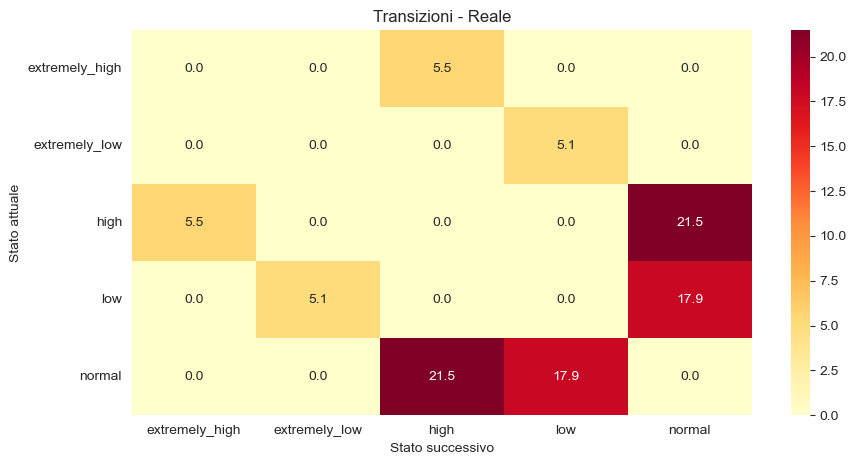

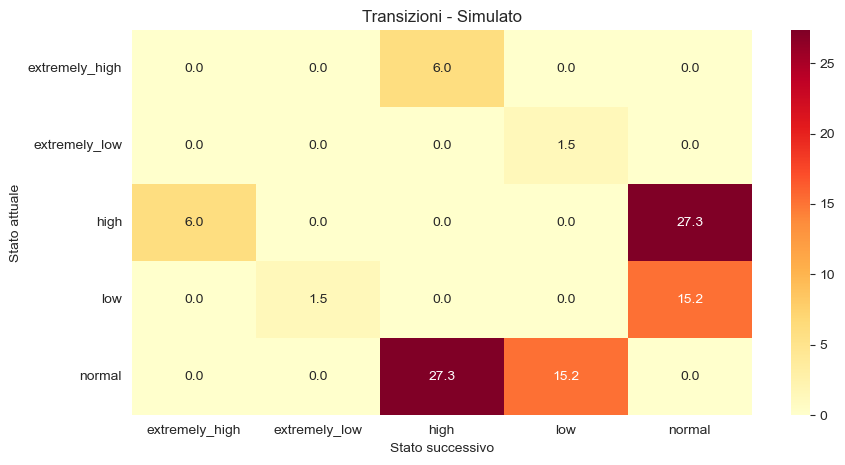

In [66]:

def plot_transition_heatmap(real_seq, sim_seq, normalize=True):
    """
    Visualizza una heatmap delle transizioni di stato per sequenze reali e simulate.

    Parametri:
    - real_seq, sim_seq: liste di tuple (state, duration) o (state, duration, glucose)
    - normalize: se True, mostra frequenze relative (%)
    """

    def get_transitions(seq):
        trans = Counter()
        for i in range(len(seq) - 1):
            s1 = seq[i][0]
            s2 = seq[i + 1][0]
            trans[(s1, s2)] += 1
        return trans

    # Transizioni
    real_trans = get_transitions(real_seq)
    sim_trans = get_transitions(sim_seq)

    # Tutti gli stati coinvolti
    all_states = sorted(set([s for s, _ in real_trans.keys()] + [s for _, s in real_trans.keys()] +
                            [s for s, _ in sim_trans.keys()] + [s for _, s in sim_trans.keys()]))

    # Matrice reale
    real_matrix = [[real_trans.get((i, j), 0) for j in all_states] for i in all_states]
    sim_matrix = [[sim_trans.get((i, j), 0) for j in all_states] for i in all_states]

    if normalize:
        # Frequenze relative
        total_real = sum(real_trans.values())
        total_sim = sum(sim_trans.values())
        real_matrix = [[v / total_real * 100 for v in row] for row in real_matrix]
        sim_matrix = [[v / total_sim * 100 for v in row] for row in sim_matrix]

    # Heatmap reale
    plt.figure(figsize=(10, 5))
    sns.heatmap(real_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Reale")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()

    # Heatmap simulata
    plt.figure(figsize=(10, 5))
    sns.heatmap(sim_matrix, annot=True, fmt=".1f" if normalize else "d",
                xticklabels=all_states, yticklabels=all_states, cmap="YlOrRd")
    plt.title("Transizioni - Simulato")
    plt.xlabel("Stato successivo")
    plt.ylabel("Stato attuale")
    plt.show()


plot_transition_heatmap(seq, sim_seq, normalize=True)


## Algoritmo per assegnare soglie alle squenze

In [67]:
THRESHOLDS_DURATION = {
    "high": 90,
    "low": 30,
    "extremely_high": 45,
    "extremely_low": 10,
}


def analyze_simulate_sequence_compact(seq, analize_day=None):
    """
    Analisi compatta della sequenza.
    Restituisce solo lo stato finale (🟢🟡🔴) e il numero totale di anomalie.
    """
    if analize_day is None:
        total_minutes = sum(item[1] for item in seq)  # usa sempre il secondo elemento = durata
        analize_day = round(total_minutes / 1440)
    max_minutes = analize_day * 1440
    elapsed = 0

    states = ["extremely_high", "high", "normal", "low", "extremely_low"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}

    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    prev_state = None
    for item in seq:
        state = item[0]
        duration = item[1]

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state
        elapsed += duration
        if elapsed >= max_minutes:
            break
        if state in counts:
            counts[state] += 1
            durations[state] += duration

    average_duration = {s: (durations[s] / counts[s] if counts[s] > 0 else 0) for s in states}

    thresholds_frequency = {
        "high": 3 * analize_day,
        "low": 3 * analize_day,
        "extremely_high": analize_day,
        "extremely_low": analize_day,
    }

    anomalies_frequency = sum(
        counts[s] >= thresholds_frequency.get(s, float('inf'))
        for s in thresholds_frequency
    )
    anomalies_duration = sum(
        average_duration[s] >= THRESHOLDS_DURATION.get(s, float('inf'))
        for s in THRESHOLDS_DURATION
    )
    total_anomalies = anomalies_frequency + anomalies_duration

    if total_anomalies <= 2:
        status = "🟢 Verde"
    elif total_anomalies <= 4:
        status = "🟡 Giallo"
    else:
        status = "🔴 Rosso"

    return status, total_anomalies


def plot_sequence(seq, index=None, status=None):
    """
    Crea un grafico per visualizzare l'evoluzione dello stato nel tempo.
    Compatibile con sequenze (state, duration) o (state, duration, glucose_value)
    """
    state_map = {
        "extremely_low": -2,
        "low": -1,
        "normal": 0,
        "high": 1,
        "extremely_high": 2
    }
    color_map = {
        -2: "#0044cc",  # blu
        -1: "#00aaff",  # azzurro
        0: "#00cc44",  # verde
        1: "#ffcc00",  # giallo
        2: "#ff3300"  # rosso
    }

    times = [0]
    values = [state_map[seq[0][0]] if seq else 0]

    for item in seq:
        state = item[0]
        duration = item[1]
        times.append(times[-1] + duration)
        values.append(state_map[state])

    plt.figure(figsize=(10, 3))
    for i in range(1, len(times)):
        plt.plot(times[i - 1:i + 1], values[i - 1:i + 1], color=color_map[values[i]], linewidth=2)
    plt.yticks([-2, -1, 0, 1, 2], ["ext_low", "low", "normal", "high", "ext_high"])
    plt.xlabel("Tempo (minuti)")
    plt.title(f"Sequenza {index} – Stato finale: {status}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def generate_and_test_models_compact(number_models=10, total_days=7, show_graph=True):
    total_minutes = total_days * 1440  # conversione giorni → minuti
    results = []

    for i in range(number_models):
        seq, target, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(G, total_minutes)
        status, anomalies = analyze_simulate_sequence_compact(seq)
        results.append((status, anomalies, target))

        print(f"Modello {i}: {status}, anomalie: {anomalies}, target: {target}")

        if show_graph:
            plot_sequence(seq, index=i, status=status)

    status_counts = Counter([status for status, _, _ in results])
    anomalies_list = [anomalies for _, anomalies, _ in results]

    summary = {
        "status_counts": status_counts,
        "min_anomalies": min(anomalies_list),
        "max_anomalies": max(anomalies_list),
        "avg_anomalies": sum(anomalies_list) / len(anomalies_list)
    }

    print("\n" + "=" * 60)
    print(" RIEPILOGO DEI MODELLI ".center(60))
    print("=" * 60)
    for s, c in summary["status_counts"].items():
        perc = (c / len(results)) * 100
        print(f"{s}: {c} modelli ({perc:.1f}%)")
    print("-" * 60)
    print(f"Anomalie - min: {summary['min_anomalies']}, "
          f"max: {summary['max_anomalies']}, "
          f"media: {summary['avg_anomalies']:.2f}")
    print("=" * 60)

    return results, summary

## CODICE DI PROVA PER GENERARE ED ETICHETTARE MODELLI

Modello 0: 🟢 Verde, anomalie: 1, target: 🟢 Verde


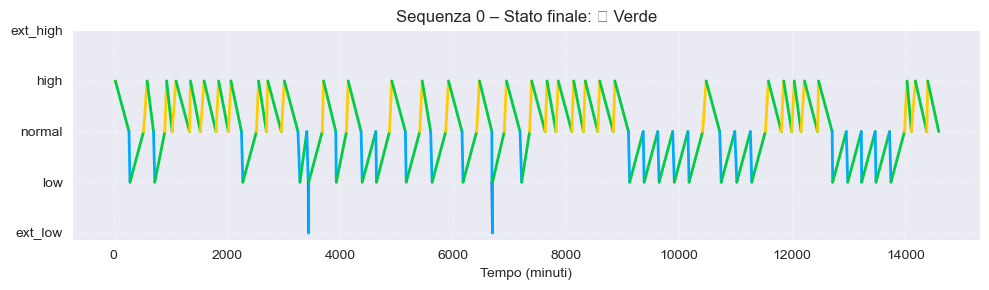

Modello 1: 🟢 Verde, anomalie: 2, target: 🟢 Verde


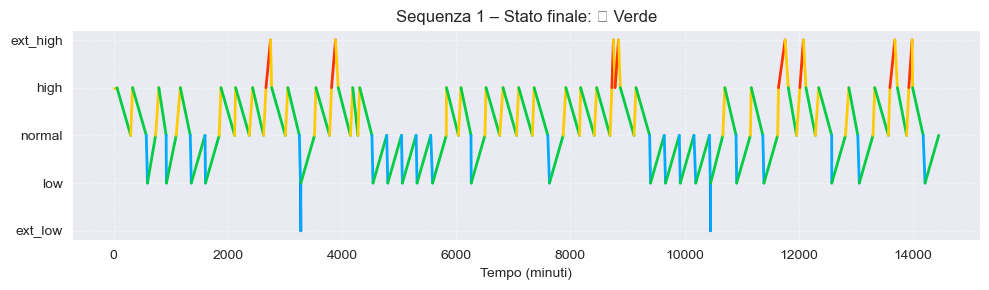

Modello 2: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


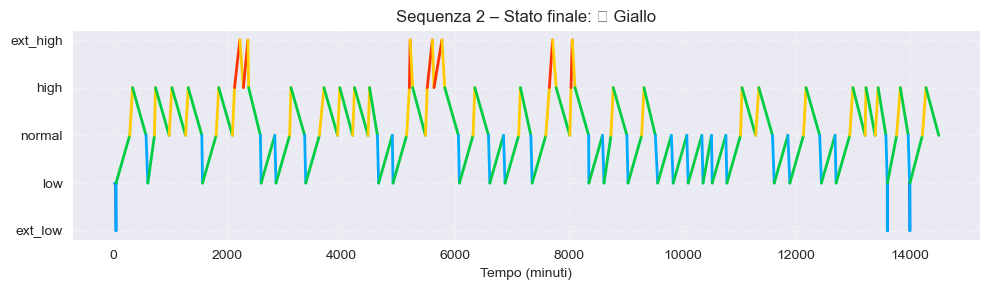

Modello 3: 🟢 Verde, anomalie: 1, target: 🟢 Verde


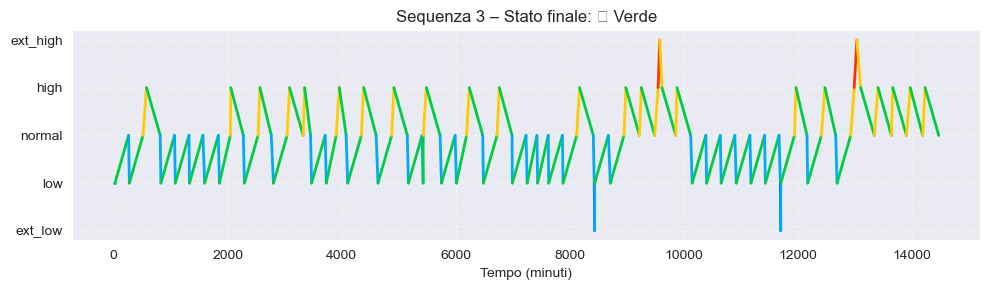

Modello 4: 🟢 Verde, anomalie: 1, target: 🟢 Verde


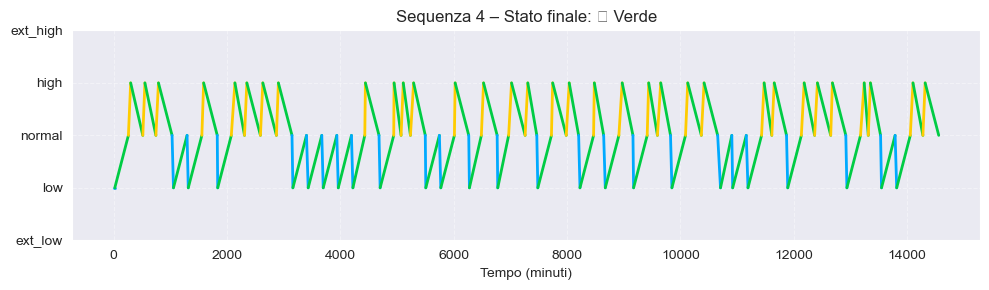

Modello 5: 🟢 Verde, anomalie: 1, target: 🟢 Verde


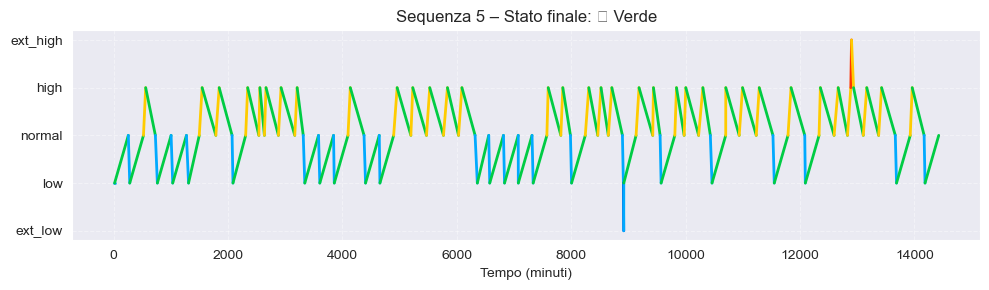

Modello 6: 🟢 Verde, anomalie: 1, target: 🟢 Verde


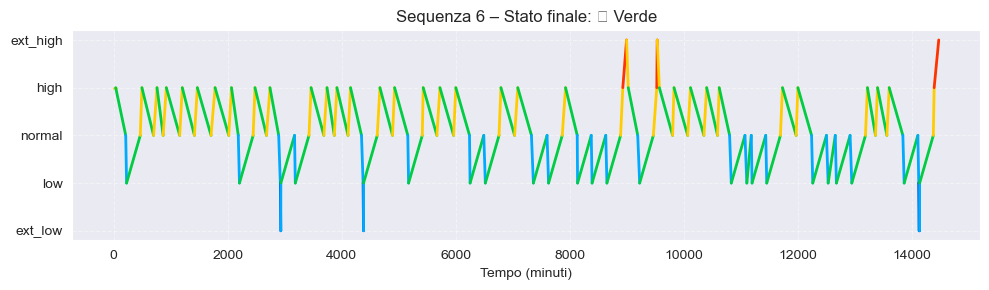

Modello 7: 🟢 Verde, anomalie: 1, target: 🟢 Verde


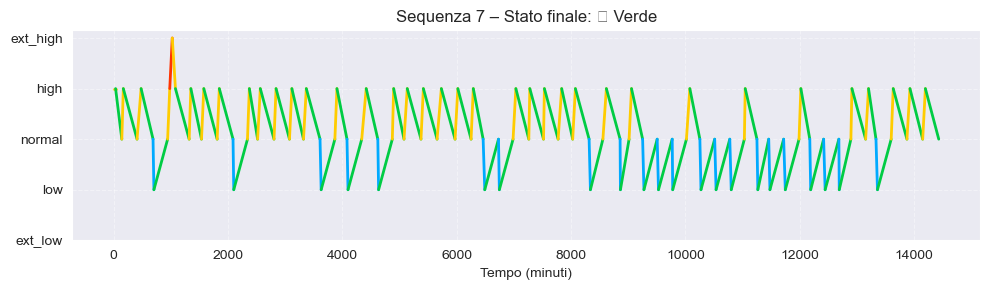

Modello 8: 🟢 Verde, anomalie: 2, target: 🟢 Verde


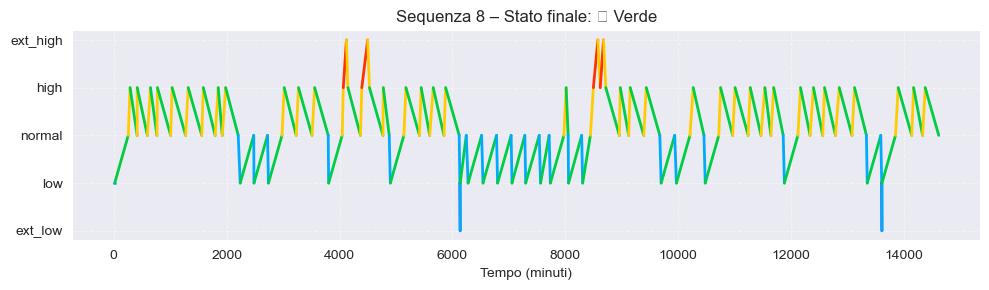

Modello 9: 🔴 Rosso, anomalie: 5, target: 🔴 Rosso


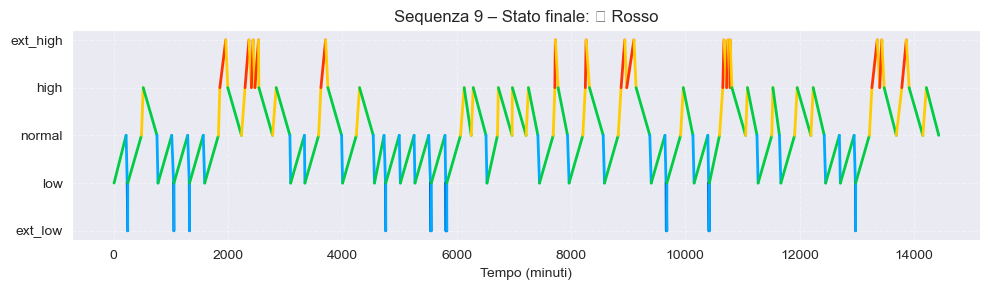

Modello 10: 🟢 Verde, anomalie: 2, target: 🟢 Verde


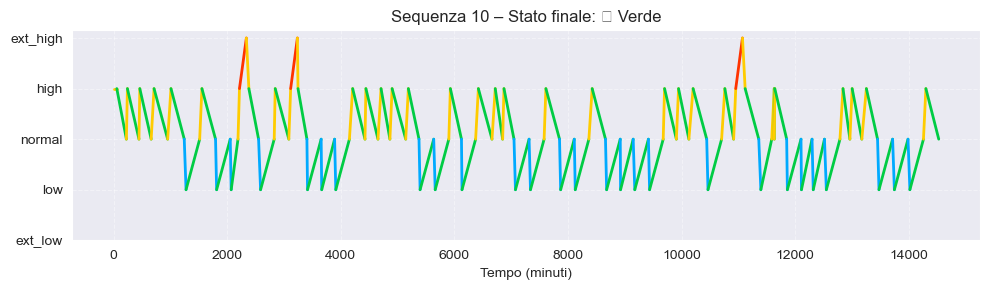

Modello 11: 🟢 Verde, anomalie: 2, target: 🟢 Verde


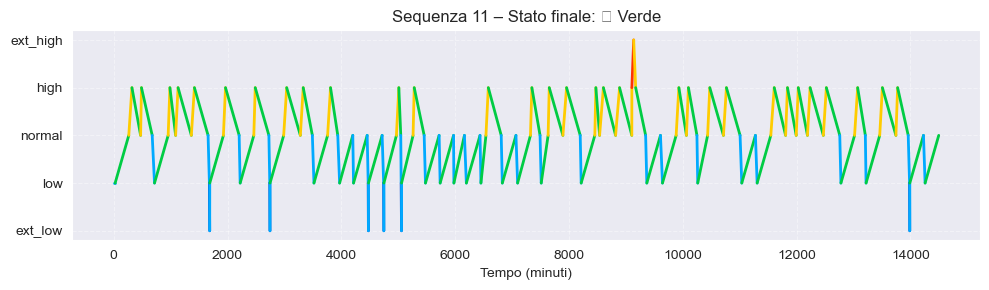

Modello 12: 🟡 Giallo, anomalie: 3, target: 🟡 Giallo


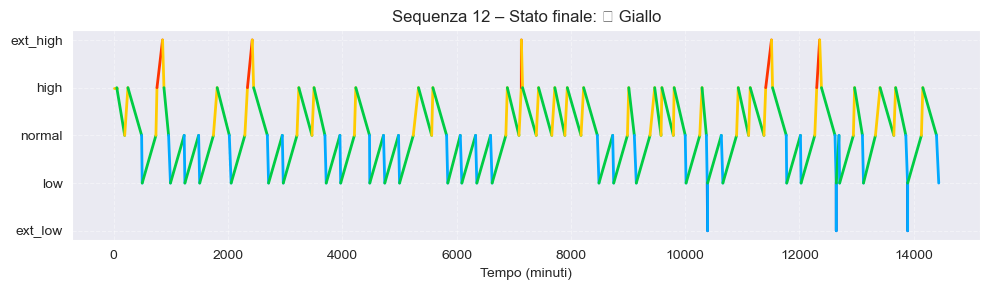

Modello 13: 🟢 Verde, anomalie: 1, target: 🟢 Verde


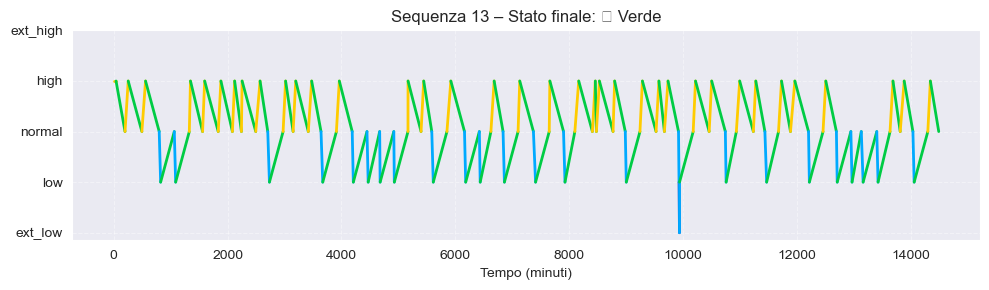

Modello 14: 🟢 Verde, anomalie: 2, target: 🟢 Verde


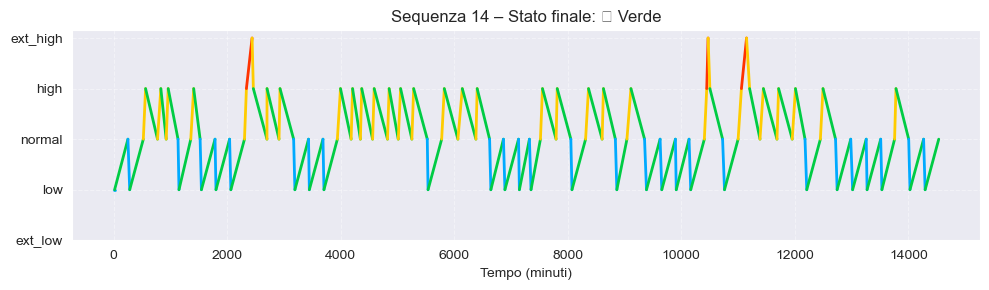

Modello 15: 🟢 Verde, anomalie: 2, target: 🟢 Verde


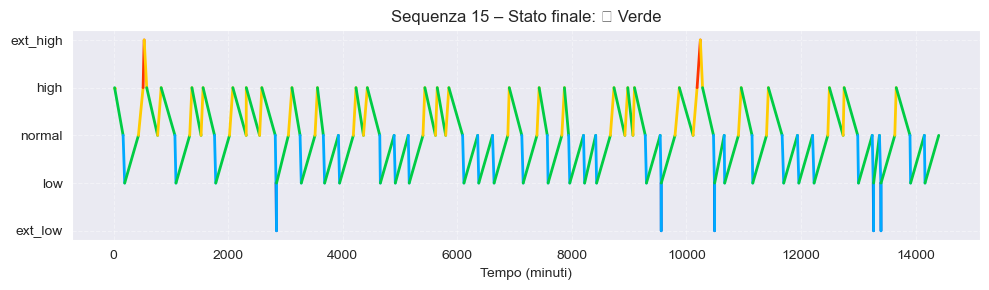

Modello 16: 🟢 Verde, anomalie: 1, target: 🟢 Verde


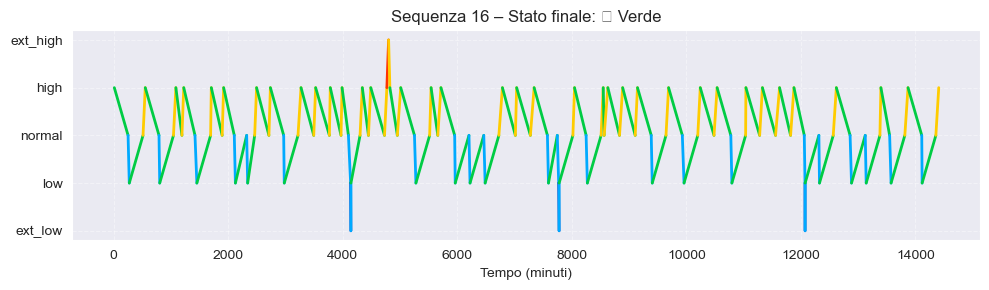

Modello 17: 🟢 Verde, anomalie: 2, target: 🟢 Verde


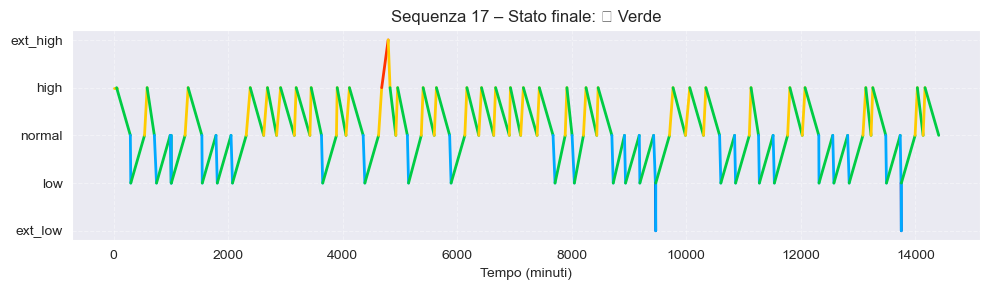

Modello 18: 🟢 Verde, anomalie: 2, target: 🟢 Verde


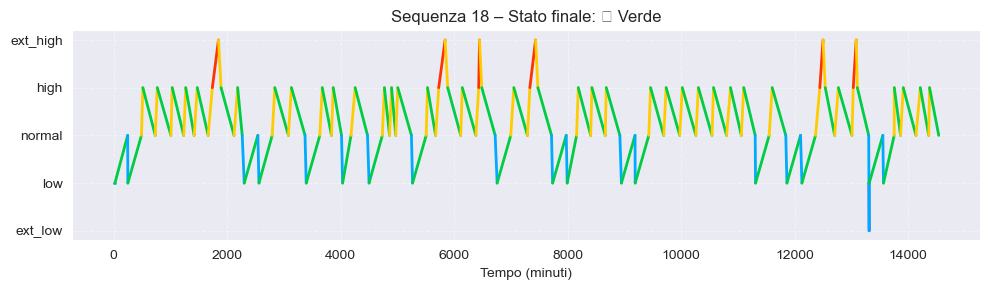

Modello 19: 🟢 Verde, anomalie: 2, target: 🟢 Verde


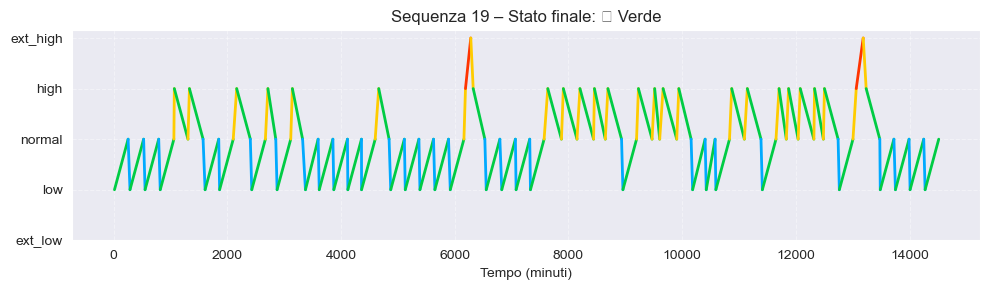


                   RIEPILOGO DEI MODELLI                    
🟢 Verde: 17 modelli (85.0%)
🟡 Giallo: 2 modelli (10.0%)
🔴 Rosso: 1 modelli (5.0%)
------------------------------------------------------------
Anomalie - min: 1, max: 5, media: 1.85
Modello 0: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 1: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 2: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Giallo
Modello 3: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 4: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 5: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 6: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 7: 🟢 Verde, anomalie: 1, target simulato: 🟢 Verde
Modello 8: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 9: 🔴 Rosso, anomalie: 5, target simulato: 🔴 Rosso
Modello 10: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 11: 🟢 Verde, anomalie: 2, target simulato: 🟢 Verde
Modello 12: 🟡 Giallo, anomalie: 3, target simulato: 🟡 Gi

In [73]:

results, summary = generate_and_test_models_compact(number_models=20, total_days=10)

for i, (status, anomalies, target) in enumerate(results):
    print(f"Modello {i}: {status}, anomalie: {anomalies}, target simulato: {target}")

print("\n" + "=" * 60)
print(" RIEPILOGO DEI MODELLI".center(60))
print("=" * 60)

for s, c in summary["status_counts"].items():
    perc = (c / len(results)) * 100
    print(f"{s}: {c} modelli ({perc:.1f}%)")

print("-" * 60)
print(f"Anomalie - min: {summary['min_anomalies']}, "
      f"max: {summary['max_anomalies']}, "
      f"media: {summary['avg_anomalies']:.2f}")

if "mode_counts" in summary:
    print("\nModalità globali simulate:")
    for m, c in summary["mode_counts"].items():
        print(f"{m}: {c} modelli ({c / len(results) * 100:.1f}%)")

print("=" * 60)

## GENERAZIONE E ASSEGNAZIONE TARGET ALLE SEQUENZE SIMULATE

In [120]:

def extract_features(seq, max_minutes=None):
    """Estrae feature numeriche da una sequenza per ML (compatibile con valori glicemici)."""
    states = ["extremely_high", "high", "normal", "low", "extremely_low"]
    counts = {s: 0 for s in states}
    durations = {s: 0 for s in states}
    transitions_of_interest = [
        ("normal", "high"), ("normal", "low"),
        ("low", "normal"), ("low", "extremely_low"),
        ("high", "normal"), ("high", "extremely_high"),
        ("extremely_low", "low"), ("extremely_high", "high")
    ]
    transition_counts = {t: 0 for t in transitions_of_interest}

    elapsed = 0
    prev_state = None

    glucose_values = []  # 👈 aggiunto per tenere traccia dei valori glicemici medi

    for item in seq:
        # Compatibilità 2 o 3 valori
        if len(item) == 3:
            state, dur, glucose = item
            glucose_values.append(glucose)
        else:
            state, dur = item

        if prev_state is not None and (prev_state, state) in transition_counts:
            transition_counts[(prev_state, state)] += 1
        prev_state = state

        elapsed += dur
        if max_minutes and elapsed > max_minutes:
            break

        counts[state] += 1
        durations[state] += dur

    total_time = sum(durations.values())
    features = {}

    for s in states:
        features[f"perc_{s}"] = durations[s] / total_time if total_time > 0 else 0
        features[f"avg_dur_{s}"] = durations[s] / counts[s] if counts[s] > 0 else 0

    # numero transizioni
    for t, c in transition_counts.items():
        features[f"trans_{t[0]}_{t[1]}"] = c

    # Valori glicemici medi (se presenti)
    if glucose_values:
        features["avg_glucose"] = np.mean(glucose_values)
        features["std_glucose"] = np.std(glucose_values)
        gmi = 3.31 + 0.02392 * features["avg_glucose"]
        features["gmi"] = gmi

        if gmi < 7:
            features["gmi_color"] = "🟢 Verde"
        elif gmi < 8:
            features["gmi_color"] = "🟡 Giallo"
        else:
            features["gmi_color"] = "🔴 Rosso"

    # stato finale (target) → calcolato come prima
    status, _ = analyze_simulate_sequence_compact(seq)
    features["target"] = status

    return features

import os
from datetime import datetime, timedelta
import pandas as pd

STATE_SYMBOL = {
    "extremely_high": "a",
    "high": "b",
    "normal": "c",
    "low": "d",
    "extremely_low": "e"
}


def save_intervals_csv(seq, filename, start_time="2024-02-13 00:01:32"):
    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    current_time = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    rows = []

    for state, duration, glucose in seq:
        start_dt = current_time
        end_dt = current_time + timedelta(minutes=duration)
        rows.append({
            "Symbol": STATE_SYMBOL[state],
            "Start time": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "End time": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "Event": state,
            "Duration": str(end_dt - start_dt),
            "Avg_Glucose": round(glucose, 1)
        })
        current_time = end_dt

    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"[OK] Dexcom CSV → {filename}")


def save_intervals_epoch_simple(seq, filename, start_time="2024-02-13 00:01:32"):
    if os.path.exists(filename):
        return  # già salvato

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    start_dt = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    current_epoch = int(start_dt.timestamp())
    rows = []

    for state, duration, glucose in seq:
        start_e = current_epoch
        end_e = current_epoch + int(duration * 60)
        rows.append({
            "start_time": start_e,
            "end_time": end_e,
            "label": state
        })
        current_epoch = end_e

    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"[OK] Epoch-simple CSV → {filename}")


In [131]:
output_dir = "simulated_intervals"
os.makedirs(output_dir, exist_ok=True)

saved_colors = {"verde": False, "giallo": False, "rosso": False}

num_sequences = 30000
total_days = 20
total_minutes = total_days * 1440
data = []

# Tracciamo quali colori abbiamo già salvato
saved_colors = {"verde": False, "giallo": False, "rosso": False}

num_sequences = 30000
total_days = 20
total_minutes = total_days * 1440
data = []

for i in range(num_sequences):
    seq, true_color, gmi, avg_gluc, gmi_color = simulate_random_sequence_realistic(G, total_minutes)
    features = extract_features(seq, max_minutes=total_minutes)
    features["target"] = true_color
    features["sequence"] = seq
    data.append(features)

    # STANDARDIZZA il colore in chiave semplice
    if "verde" in true_color.lower():
        color_key = "verde"
    elif "giallo" in true_color.lower():
        color_key = "giallo"
    elif "rosso" in true_color.lower():
        color_key = "rosso"
    else:
        continue  # se per caso un colore non previsto

    if not saved_colors[color_key]:
        labeling_file = f"{output_dir}/{color_key}_labeling.csv"
        epoch_file = f"{output_dir}/{color_key}_epoch.csv"
        save_intervals_csv(seq, labeling_file)
        save_intervals_epoch_simple(seq, epoch_file)
        saved_colors[color_key] = True

df = pd.DataFrame(data)

# Statistiche dei target
target_counts = df['target'].value_counts()
total = target_counts.sum()
print("Distribuzione dei target nel dataset:")
for target, count in target_counts.items():
    perc = count / total * 100
    print(f"{target}: {count} sequenze ({perc:.1f}%)")

[OK] Dexcom CSV → simulated_intervals/verde_labeling.csv
[OK] Epoch-simple CSV → simulated_intervals/verde_epoch.csv
[OK] Dexcom CSV → simulated_intervals/giallo_labeling.csv
[OK] Epoch-simple CSV → simulated_intervals/giallo_epoch.csv
[OK] Dexcom CSV → simulated_intervals/rosso_labeling.csv
[OK] Epoch-simple CSV → simulated_intervals/rosso_epoch.csv
Distribuzione dei target nel dataset:
🟢 Verde: 19618 sequenze (65.4%)
🟡 Giallo: 7462 sequenze (24.9%)
🔴 Rosso: 2920 sequenze (9.7%)


In [123]:
analyze_simulate_sequence_compact(df['sequence'][100])

('🟢 Verde', 2)

In [124]:
df[1000:]

,perc_extremely_high,avg_dur_extremely_high,perc_high,avg_dur_high,perc_normal,avg_dur_normal,perc_low,avg_dur_low,perc_extremely_low,avg_dur_extremely_low,...,trans_high_normal,trans_high_extremely_high,trans_extremely_low_low,trans_extremely_high_high,avg_glucose,std_glucose,gmi,gmi_color,target,sequence
1000,0.022559,71.944444,0.103729,41.351389,0.837684,218.579091,0.035781,20.959184,0.000247,7.100000,...,63,9,1,9,148.355785,64.012978,6.858670,🟢 Verde,🟢 Verde,"[(high, 46.9, 243.7), (normal, 240, 109.5), (l..."
1001,0.042136,54.818182,0.107213,40.376316,0.807522,214.004630,0.041420,19.120968,0.001709,6.985714,...,54,22,7,22,148.851087,71.823303,6.870518,🟢 Verde,🟡 Giallo,"[(high, 39.3, 184.4), (normal, 206.9, 111.6), ..."
1002,0.078031,77.251724,0.124429,41.539535,0.759272,215.831683,0.034099,13.788732,0.004169,4.603846,...,57,29,26,29,147.722930,79.366308,6.843532,🟢 Verde,🔴 Rosso,"[(low, 15.5, 76.8), (normal, 240, 127.6), (hig..."
1003,0.004617,66.100000,0.100480,43.595455,0.857716,213.575652,0.036615,19.063636,0.000573,5.466667,...,64,2,3,2,136.919835,59.612743,6.585122,🟢 Verde,🟢 Verde,"[(high, 52.6, 245.0), (normal, 185.4, 177.9), ..."
1004,0.011357,81.275000,0.093782,42.612698,0.851323,213.771053,0.041602,18.043939,0.001935,5.540000,...,59,4,10,4,136.031008,64.646572,6.563862,🟢 Verde,🟡 Giallo,"[(low, 24.9, 70.8), (normal, 240, 86.0), (high..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.006481,93.300000,0.093672,42.137500,0.859023,215.053043,0.040205,20.307018,0.000618,4.450000,...,62,2,4,2,137.685185,60.251875,6.603430,🟢 Verde,🟢 Verde,"[(high, 58.3, 209.8), (normal, 154.4, 170.2), ..."
29996,0.004717,67.650000,0.096719,40.207246,0.862652,213.313793,0.035215,18.705556,0.000697,5.000000,...,67,2,4,2,141.142276,58.890706,6.686123,🟢 Verde,🟢 Verde,"[(high, 75.3, 189.7), (normal, 198.2, 149.8), ..."
29997,0.011177,80.400000,0.108976,42.372973,0.843171,207.357265,0.036190,20.826000,0.000487,4.666667,...,70,4,3,4,143.144177,60.381353,6.734009,🟢 Verde,🟢 Verde,"[(low, 14.3, 67.5), (normal, 124.6, 130.1), (h..."
29998,0.026661,76.700000,0.114088,43.185526,0.820694,205.302609,0.036714,18.529825,0.001842,7.571429,...,66,10,7,10,147.525940,66.310081,6.838820,🟢 Verde,🟢 Verde,"[(high, 48.0, 200.1), (extremely_high, 47.7, 3..."


In [125]:
df[["gmi", "gmi_color", "target"]]

,gmi,gmi_color,target
0,6.959999,🟢 Verde,🔴 Rosso
1,7.111671,🟡 Giallo,🔴 Rosso
2,6.698568,🟢 Verde,🟡 Giallo
3,6.931083,🟢 Verde,🟢 Verde
4,6.671583,🟢 Verde,🟢 Verde
...,...,...,...
29995,6.603430,🟢 Verde,🟢 Verde
29996,6.686123,🟢 Verde,🟢 Verde
29997,6.734009,🟢 Verde,🟢 Verde
29998,6.838820,🟢 Verde,🟢 Verde


## Apprendimento per riconoscere target sulle sequenze


Distribuzione delle classi in Train/Test:


,Classe,Train (%),Test (%),Totale (%)
0,🔴 Rosso,9.64,9.63,9.64
1,🟡 Giallo,24.99,24.98,24.99
2,🟢 Verde,65.38,65.38,65.38



=== Random Forest ===

Classification Report:

              precision    recall  f1-score   support

     🔴 Rosso       1.00      1.00      1.00       578
    🟡 Giallo       0.96      1.00      0.98      1499
     🟢 Verde       1.00      0.98      0.99      3923

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



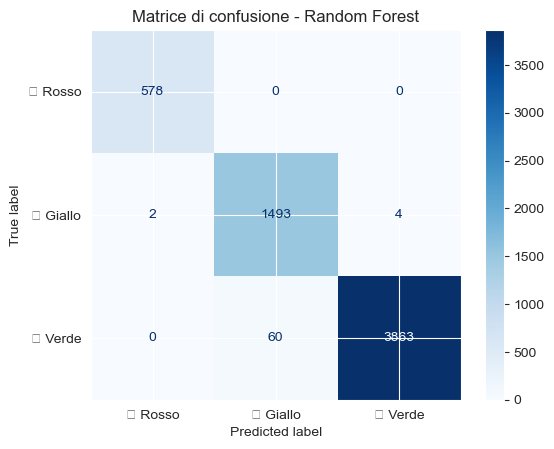


=== XGBoost ===

Classification Report:

              precision    recall  f1-score   support

     🔴 Rosso       1.00      1.00      1.00       578
    🟡 Giallo       1.00      1.00      1.00      1499
     🟢 Verde       1.00      1.00      1.00      3923

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



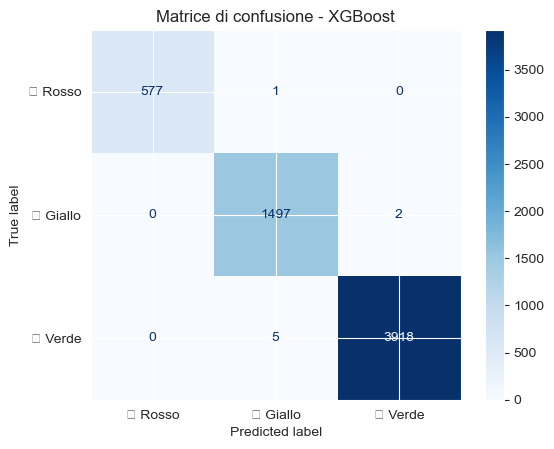


=== MLP ===

Classification Report:

              precision    recall  f1-score   support

     🔴 Rosso       1.00      1.00      1.00       578
    🟡 Giallo       0.98      0.99      0.99      1499
     🟢 Verde       1.00      0.99      1.00      3923

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



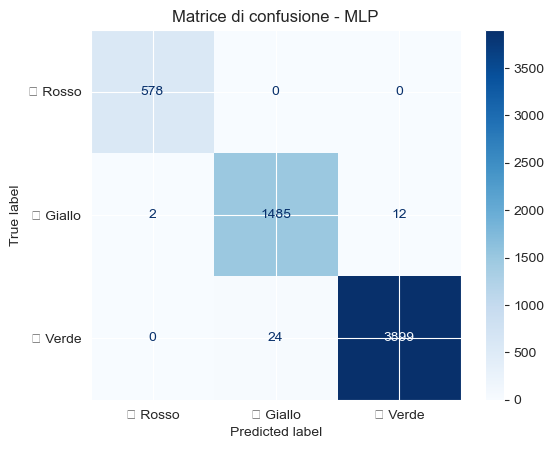

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# --- Preparazione dati ---
color_map = {"🟢 Verde": 0, "🟡 Giallo": 1, "🔴 Rosso": 2}
df["gmi_color_num"] = df["gmi_color"].map(color_map)
X = df.drop(columns=["target", "sequence", "gmi_color", "gmi"])
y = df["target"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Distribuzione classi
train_dist = np.bincount(y_train) / len(y_train)
test_dist = np.bincount(y_test) / len(y_test)

check_df = pd.DataFrame({
    "Classe": le.classes_,
    "Train (%)": np.round(train_dist * 100, 2),
    "Test (%)": np.round(test_dist * 100, 2),
    "Totale (%)": np.round((np.bincount(y_train) + np.bincount(y_test)) / (len(y_train) + len(y_test)) * 100, 2)
})

print("\nDistribuzione delle classi in Train/Test:")
display(check_df)

# --- Definizione modelli ---
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, objective='multi:softprob',
                             random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=200, random_state=42)
}

# --- Addestramento e valutazione ---
for name, clf in models.items():
    print(f"\n=== {name} ===")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice di confusione - {name}")
    plt.show()

## Clustering

Numero sequenze: 30000


Conteggio n-gram: 100%|██████████| 30000/30000 [00:07<00:00, 4196.30it/s]


Vocabolario n-gram: 90 termini


Vettorizzazione: 100%|██████████| 30000/30000 [00:07<00:00, 4142.66it/s]


Shape matrice sparsa: (30000, 90)
Eseguo UMAP...
Eseguo PCA (2 componenti)...
Varianza spiegata PCA: 18.79%


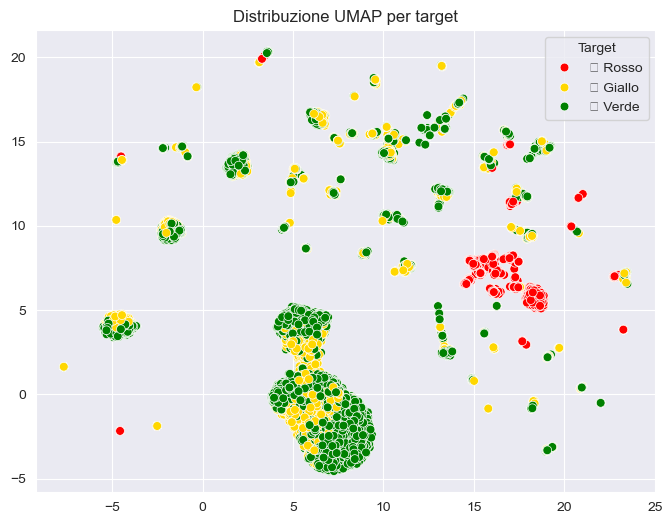

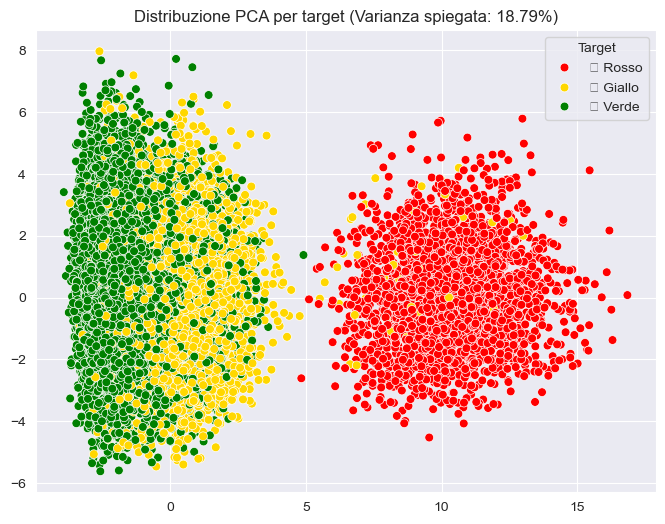

In [127]:
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Parametri principali
# -----------------------------
NGRAM_N = 3
TOP_K_NGRAMS = 3000
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
RANDOM_STATE = 42

# -----------------------------
# Funzioni ausiliarie
# -----------------------------
def discretize_duration_by_state(state, dur, thresholds):
    """
    Discretizza la durata di uno stato in breve (N) o lunga (L) rispetto alla soglia specifica.
    """
    thr = thresholds.get(state, 30)
    return "N" if dur < thr else "L"


def build_ngram_vocab(sequences, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Costruisce il vocabolario dei n-gram più frequenti da una lista di sequenze.
    """
    counter = Counter()
    for seq in tqdm(sequences, desc="Conteggio n-gram"):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        # Genera n-gram e aggiorna contatore
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i+n], durs[i:i+n]))
            counter[ng] += 1
    # Restituisce solo i top_k n-gram più frequenti
    return [ng for ng, _ in counter.most_common(top_k)]


def sequences_to_sparse_matrix(sequences, vocab, n=NGRAM_N):
    """
    Trasforma le sequenze in una matrice sparsa n-gram (conteggio frequenze).
    """
    vocab_index = {ng: i for i, ng in enumerate(vocab)}
    row_idx, col_idx, data = [], [], []

    for seq_id, seq in enumerate(tqdm(sequences, desc="Vettorizzazione")):
        if len(seq) < n:
            continue
        states = [s for s, _, _ in seq]
        durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, _ in seq]
        counts = Counter()
        for i in range(len(seq) - n + 1):
            ng = "_".join(f"{st}({du})" for st, du in zip(states[i:i+n], durs[i:i+n]))
            if ng in vocab_index:
                counts[vocab_index[ng]] += 1
        for col, c in counts.items():
            row_idx.append(seq_id)
            col_idx.append(col)
            data.append(c)

    return csr_matrix((data, (row_idx, col_idx)), shape=(len(sequences), len(vocab)))


def analyze_distribution_by_target(df, n=NGRAM_N, top_k=TOP_K_NGRAMS):
    """
    Analizza la distribuzione delle sequenze per target usando UMAP e PCA.
    """
    if df.empty:
        print("Dataset vuoto.")
        return

    sequences = df["sequence"].tolist()
    print(f"Numero sequenze: {len(sequences)}")

    # 1. Costruzione vocabolario n-gram
    vocab = build_ngram_vocab(sequences, n=n, top_k=top_k)
    print(f"Vocabolario n-gram: {len(vocab)} termini")

    # 2. Creazione matrice sparsa
    X_sparse = sequences_to_sparse_matrix(sequences, vocab, n=n)
    print(f"Shape matrice sparsa: {X_sparse.shape}")

    # 3. Standardizzazione
    scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X_sparse)

    # 4. UMAP embedding
    print("Eseguo UMAP...")
    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE
    )
    emb_umap = reducer.fit_transform(X_scaled)

    # 5. PCA embedding
    print("Eseguo PCA (2 componenti)...")
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    emb_pca = pca.fit_transform(X_scaled.toarray())
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"Varianza spiegata PCA: {explained_var:.2%}")

    # 6. Palette dinamica
    palette = {}
    for t in df["target"].unique():
        if "rosso" in t.lower() or "🔴" in t:
            palette[t] = "red"
        elif "giallo" in t.lower() or "🟡" in t:
            palette[t] = "gold"
        elif "verde" in t.lower() or "🟢" in t:
            palette[t] = "green"

    # 7. Visualizzazione UMAP
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_umap[:, 0], y=emb_umap[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title("Distribuzione UMAP per target")
    plt.legend(title="Target")
    plt.show()

    # 8. Visualizzazione PCA
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=emb_pca[:, 0], y=emb_pca[:, 1], hue=df["target"], palette=palette, s=40)
    plt.title(f"Distribuzione PCA per target (Varianza spiegata: {explained_var:.2%})")
    plt.legend(title="Target")
    plt.show()

    return {"emb_umap": emb_umap, "emb_pca": emb_pca, "palette": palette}

results_all = analyze_distribution_by_target(df, n=3, top_k=3000)

## Detection Pattern


 FP-Growth non completo -> analizzo solo una parte di dati (per ridurre complessità) per trovare in ogni sequenza (verde, gialla, rossa) i pattern più presenti

In [128]:
def build_detection_patterns(df, n_list=[3, 4, 5], top_k=50, use_duration=False, THRESHOLDS_DURATION=None):
    """
    Costruisce una tabella unica di pattern distintivi per target.

    Parametri:
    - df: DataFrame con colonne ["sequence","target"]
    - n_list: lista di lunghezze n per n-gram
    - top_k: numero di pattern da tenere per n
    - use_duration: se True usa le soglie di durata per S/M/L
    - THRESHOLDS_DURATION: dizionario delle soglie per discretizzazione
    """
    all_patterns = []

    for n in n_list:
        print(f"\n--- Estrazione pattern n={n} ---")
        targets = df["target"].unique()
        pattern_counts = {}
        total_counts_per_target = {}

        for target in targets:
            seqs = df[df["target"] == target]["sequence"].tolist()
            ngrams = []
            for seq in tqdm(seqs, desc=f"Estrazione n-gram {target}"):
                L = len(seq)
                if L < n: continue
                states = [s for s, d, g in seq]
                if use_duration and THRESHOLDS_DURATION:
                    durs = [discretize_duration_by_state(s, d, THRESHOLDS_DURATION) for s, d, g in seq]
                else:
                    durs = [""] * len(seq)
                for i in range(L - n + 1):
                    ng = ' → '.join(f"{st}({du})" if du else f"{st}" for st, du in zip(states[i:i + n], durs[i:i + n]))
                    ngrams.append(ng)
            pattern_counts[target] = Counter(ngrams)
            total_counts_per_target[target] = sum(pattern_counts[target].values())

        # Tutti i pattern globali
        patterns_set = set()
        for c in pattern_counts.values():
            patterns_set.update(c.keys())

        # Calcola lift e frequenze relative
        rows = []
        for pat in patterns_set:
            row = {"pattern": pat, "n": n}
            lift_values = {}
            for target in targets:
                count_in_target = pattern_counts[target].get(pat, 0)
                freq_in_target = count_in_target / total_counts_per_target[target] if total_counts_per_target[
                                                                                          target] > 0 else 0
                count_in_others = sum(pattern_counts[t].get(pat, 0) for t in targets if t != target)
                total_others = sum(total_counts_per_target[t] for t in targets if t != target)
                freq_in_others = count_in_others / total_others if total_others > 0 else 1e-9
                lift = freq_in_target / freq_in_others if freq_in_others > 0 else 0
                row[f"freq_{target}"] = freq_in_target
                row[f"lift_{target}"] = lift
                lift_values[target] = lift

            dominant_target = max(lift_values, key=lambda t: lift_values[t])
            row["dominant_target"] = dominant_target
            row["max_lift"] = lift_values[dominant_target]
            rows.append(row)

        df_n = pd.DataFrame(rows)
        df_n = df_n.sort_values("max_lift", ascending=False).head(top_k)
        all_patterns.append(df_n)

    detection_patterns = pd.concat(all_patterns, ignore_index=True)
    detection_patterns = detection_patterns.sort_values("max_lift", ascending=False).reset_index(drop=True)

    print(f"\nTotale pattern conservati: {len(detection_patterns)}")
    return detection_patterns

def plot_detection_patterns_heatmap(detection_patterns, df_targets, metric="freq"):
    """
    Visualizza una heatmap di frequenze o lift dei pattern per target.

    metric: "freq" oppure "lift"
    """
    metric = metric.lower()
    assert metric in ("freq", "lift"), "metric deve essere 'freq' o 'lift'"

    columns = [f"{metric}_{t}" for t in df_targets]

    heatmap_data = detection_patterns[columns]
    heatmap_data.index = detection_patterns['pattern']

    plt.figure(figsize=(12, max(4, len(detection_patterns) * 0.5)))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
    met_name = "Frequenze relative" if metric == "freq" else "Lift"
    plt.title(f"Distribuzione dei pattern per target ({met_name})")
    plt.ylabel("Pattern")
    plt.xlabel("Target")
    plt.tight_layout()
    plt.show()


--- Estrazione pattern n=4 ---


Estrazione n-gram 🟢 Verde: 100%|██████████| 19613/19613 [00:03<00:00, 5590.94it/s]



--- Estrazione pattern n=5 ---


Estrazione n-gram 🟢 Verde: 100%|██████████| 19613/19613 [00:03<00:00, 5217.19it/s]



Totale pattern conservati: 10


,pattern,n,freq_🔴 Rosso,lift_🔴 Rosso,freq_🟡 Giallo,lift_🟡 Giallo,freq_🟢 Verde,lift_🟢 Verde,dominant_target,max_lift
0,extremely_low → low → extremely_low → low → ex...,5,0.017514,45.423750,0.000961,0.310874,0.000152,0.023435,🔴 Rosso,45.423750
1,extremely_high → high → extremely_high → high ...,5,0.018810,39.608863,0.000936,0.273419,0.000288,0.041626,🔴 Rosso,39.608863
2,extremely_low → low → extremely_low → low,4,0.041074,15.218671,0.005665,0.691505,0.001498,0.085528,🔴 Rosso,15.218671
3,low → extremely_low → low → extremely_low,4,0.041084,15.218287,0.005667,0.691594,0.001498,0.085516,🔴 Rosso,15.218287
4,low → extremely_low → low → extremely_low → low,5,0.041194,15.202681,0.005687,0.691478,0.001504,0.085573,🔴 Rosso,15.202681
5,extremely_high → high → extremely_high → high,4,0.045864,14.187093,0.005348,0.549459,0.002376,0.125718,🔴 Rosso,14.187093
6,high → extremely_high → high → extremely_high,4,0.046003,14.172789,0.005366,0.549566,0.002387,0.125892,🔴 Rosso,14.172789
7,high → extremely_high → high → extremely_high ...,5,0.045998,14.172186,0.005368,0.549438,0.002386,0.125784,🔴 Rosso,14.172186
8,extremely_low → low → extremely_low → low → no...,5,0.023679,10.189291,0.004725,0.920716,0.001351,0.122075,🔴 Rosso,10.189291
9,extremely_low → low → normal → low,4,0.024633,2.867945,0.013891,1.459242,0.006442,0.368439,🔴 Rosso,2.867945


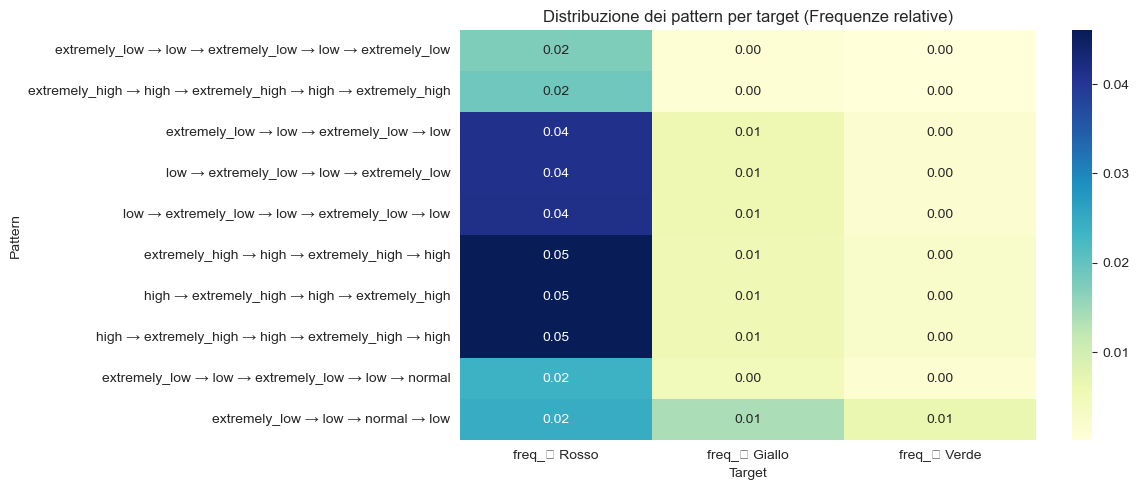

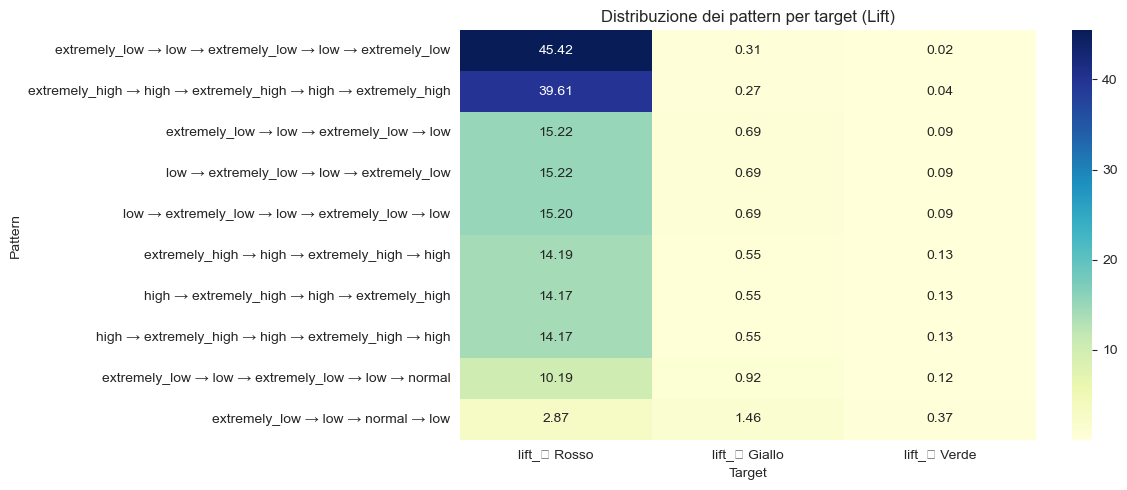

In [129]:
detection_patterns = build_detection_patterns(df, n_list=[4, 5], top_k=5, use_duration=False,
                                              THRESHOLDS_DURATION=THRESHOLDS_DURATION)
display(detection_patterns)
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="freq")
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="lift")



--- Estrazione pattern n=4 ---


Estrazione n-gram 🟢 Verde: 100%|██████████| 19613/19613 [00:04<00:00, 4088.63it/s]



--- Estrazione pattern n=5 ---


Estrazione n-gram 🟢 Verde: 100%|██████████| 19613/19613 [00:05<00:00, 3660.82it/s]



Totale pattern conservati: 10


,pattern,n,freq_🔴 Rosso,lift_🔴 Rosso,freq_🟡 Giallo,lift_🟡 Giallo,freq_🟢 Verde,lift_🟢 Verde,dominant_target,max_lift
0,extremely_low(L) → low(N) → extremely_low(N) →...,5,0.000334,46.426900,1.987614e-05,0.340859,2.064626e-06,0.016502,🔴 Rosso,46.426900
1,extremely_low(N) → low(N) → extremely_low(N) →...,5,0.000317,45.909050,1.885685e-05,0.340399,2.064626e-06,0.017398,🔴 Rosso,45.909050
2,extremely_low(N) → low(N) → extremely_low(N) →...,5,0.016534,45.464938,9.030901e-04,0.309272,1.451432e-04,0.023657,🔴 Rosso,45.464938
3,extremely_low(N) → low(N) → extremely_low(L) →...,5,0.000306,43.372807,1.783756e-05,0.330177,2.684013e-06,0.023490,🔴 Rosso,43.372807
4,extremely_low(N) → low(N) → extremely_low(L) →...,5,0.000006,41.362147,5.096445e-07,0.495266,0.000000e+00,0.000000,🔴 Rosso,41.362147
5,high(N) → extremely_high(L) → high(L) → extrem...,4,0.000003,20.702827,0.000000e+00,0.000000,2.056299e-07,0.202872,🔴 Rosso,20.702827
6,extremely_high(L) → high(L) → extremely_high(L...,4,0.000003,20.702827,0.000000e+00,0.000000,2.056299e-07,0.202872,🔴 Rosso,20.702827
7,high(L) → extremely_high(N) → high(N) → extrem...,4,0.000011,18.977591,5.077049e-07,0.212265,6.168897e-07,0.152154,🔴 Rosso,18.977591
8,low(N) → extremely_low(N) → low(N) → extremely...,4,0.036715,15.863352,4.876506e-03,0.670644,1.276756e-03,0.082227,🔴 Rosso,15.863352
9,extremely_low(N) → low(N) → extremely_low(N) →...,4,0.039501,15.244437,5.445643e-03,0.691572,1.435091e-03,0.085229,🔴 Rosso,15.244437


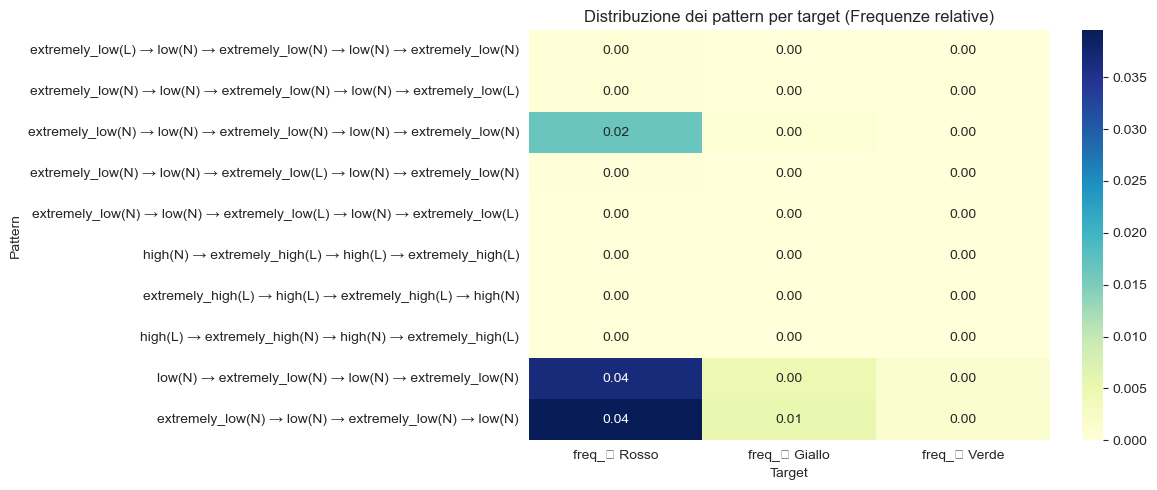

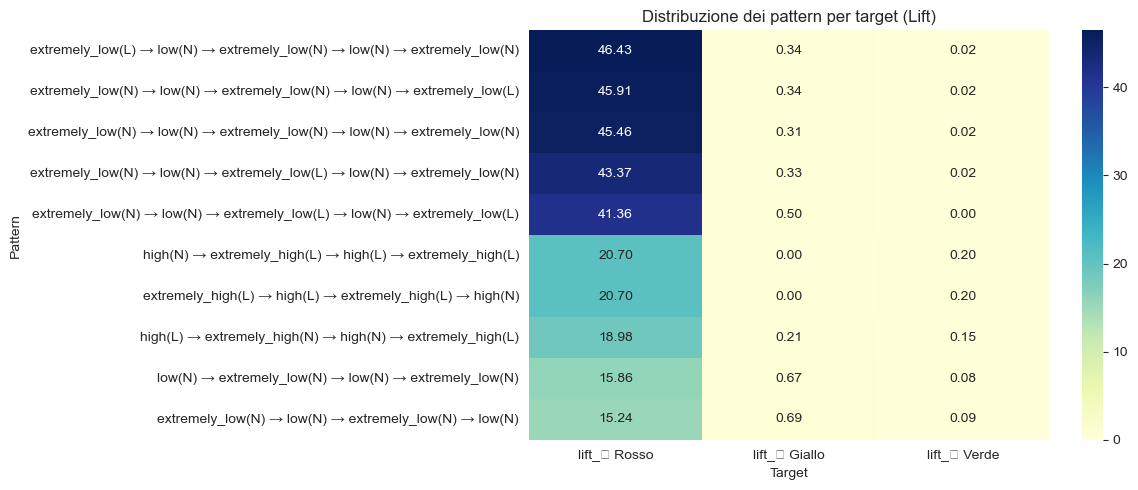

In [130]:
detection_patterns = build_detection_patterns(df, n_list=[4, 5], top_k=5, use_duration=True,
                                              THRESHOLDS_DURATION=THRESHOLDS_DURATION)
display(detection_patterns)
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="freq")
plot_detection_patterns_heatmap(detection_patterns, df["target"].unique(), metric="lift")

# CSV -> SEQUENZA

In [137]:
csv = pd.read_csv('simulated_intervals/giallo_labeling.csv')

def hms_to_minutes(hms):
    h, m, s = map(int, hms.split(":"))
    return h * 60 + m + s / 60

csv["duration_minutes"] = csv["Duration"].apply(hms_to_minutes)
csv["state"] = csv["Event"]


sequence = list(zip(csv["state"], csv["duration_minutes"]))

In [138]:
analyze_simulate_sequence_compact(sequence)

('🟡 Giallo', 3)